Isaac Noe
9/7/2026
Lab 1 — Projectile Motion Solver

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Part A — One-Dimensional Free Fall (20 points)

In [2]:
# Part 1
# Defining the Function
def simulate_freefall(h, dt, g=9.81):
    y, vy = h, 0.0
    t = 0.0
    
    t_arr, y_arr, vy_arr = [t], [y], [vy]
    
    while y >= 0:
        # Compute acceleration
        ay = -g
        
        # Euler update
        y  = y + vy * dt   
        vy = vy + ay * dt  
        t  = t + dt

        #add new values to array
        t_arr.append(t)
        y_arr.append(y)
        vy_arr.append(vy)
    
    return t_arr, y_arr, vy_arr

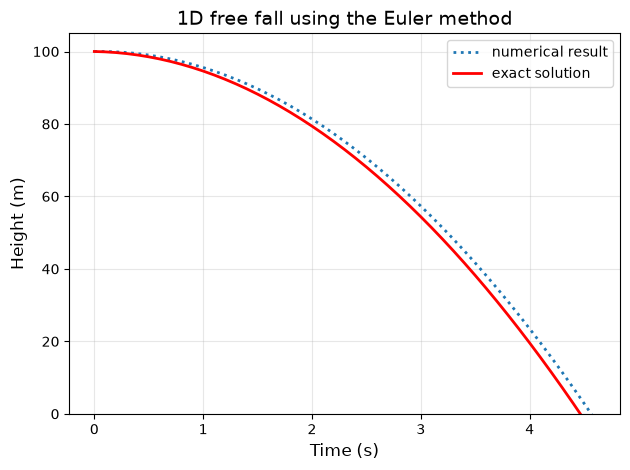

Final Numerical Velocity = -45.12600000000005m/s | Final Numerical Time = 4.6s
Final Exact Velocity = -44.145000000000046m/s | Final Exact Time = 4.5s


In [3]:
# Part 2
# Parameters
g = 9.81         # m/s², gravitational acceleration
dt = .1      # time step in seconds
h = 100          # starting height 

#Calling the Fuction
t_cal, y_cal, vy_cal = simulate_freefall(h, dt)

# Part 3
#Calculating Exact Solution

    # Storage lists for plotting
y_ex, t_ex = [h], [0.0]
vy_ex = 0
    # Euler integration loop
t = 0.0
while h >= 0.0:
        # Compute acceleration (only gravity here)
    ay = -g

        # Update velocity (Euler)
    vy_ex = vy_ex + ay * dt

        # Update position (Euler)
    h = h + vy_ex * dt

    t += dt
    y_ex.append(h)
    t_ex.append(t)

# Plotting the Graph
plt.plot(t_cal, y_cal,linestyle='dotted', label='numerical result', linewidth=2)
plt.plot(t_ex, y_ex, color='red', label='exact solution', linewidth=2)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Height (m)', fontsize=12)
plt.title('1D free fall using the Euler method', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

# Part 4
# Showing the Valuesfor comparision
print(f'Final Numerical Velocity = {vy_cal[-1]}m/s | Final Numerical Time = {t_cal[-1]}s')
print(f'Final Exact Velocity = {vy_ex}m/s | Final Exact Time = {t_ex[-1]}s')

This graph shows that the numerical solution is not as accurate as the exact solution but it becomes more accurate as dt becomes smaller.

Questions:                                                                                              
A. What is the numerical landing time? What is the exact landing time? What is the percentage error?

The numerical landing time is 4.6 seconds. The exact landing time is 4.5 seconds. The precent error is 2.17%

B. Try dt = 1.0, dt = 0.1, and dt = 0.01. How does the error change? (One sentence is fine.)

The error lessens as dt decreases.

Part B — Two-Dimensional Projectile (35 points)

In [4]:
# Part 1
def simulate_projectile_2d(v0, theta_deg,dt, g=9.81):

    # Initial conditions:
    angle = np.radians(theta_deg)
    x, y = 0.0, 0.0
    vx, vy = v0 * np.cos(angle), v0 * np.sin(angle)

    # Storage lists for plotting
    xs, ys, ts, vxs, vys, speed_s = [x], [y], [0.0], [vx], [vy], [np.sqrt(vx**2 + vy**2)]

    t = 0.0
    while y >= 0.0:
        # Compute acceleration (only gravity here)
        ax = 0.0
        ay = -g

        # Speed
        speed = np.sqrt(vx**2 + vy**2)

        # Update velocity (Euler)
        vx = vx + ax * dt
        vy = vy + ay * dt

        # Update position (Euler)
        x = x + vx * dt
        y = y + vy * dt

        t += dt
        xs.append(x)
        ys.append(y)
        ts.append(t)
        vxs.append(vx)
        vys.append(vy)
        speed_s.append(speed)
    return xs, ys, vxs, vys, ts, speed_s

In [5]:
# Part 2
# Calling the Function
x, y, vx, vy, t ,speed = simulate_projectile_2d(30,45,0.01)

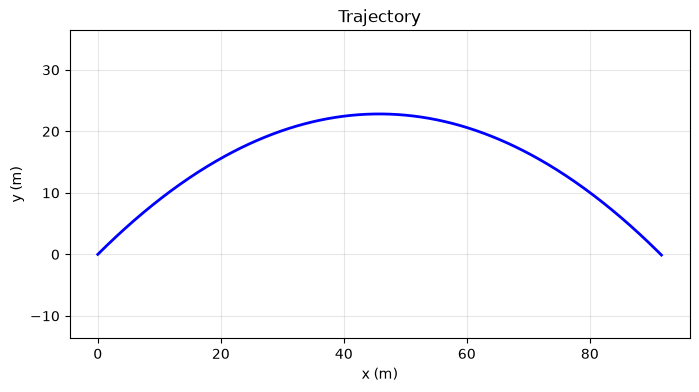

Range = 91.64103884177646m | Max Height = 22.829803420888364m | Time = 4.319999999999952s


In [6]:
# Part 3
# Plotting Graph
plt.figure(figsize=(8, 4))
plt.plot(x, y, 'b-', linewidth=2)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Trajectory')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

# Results
print(f'Range = {x[-1]}m | Max Height = {y[len(y) // 2]}m | Time = {t[-1]}s')

This graph shows the height of the projectile as it progresses in the x direction.

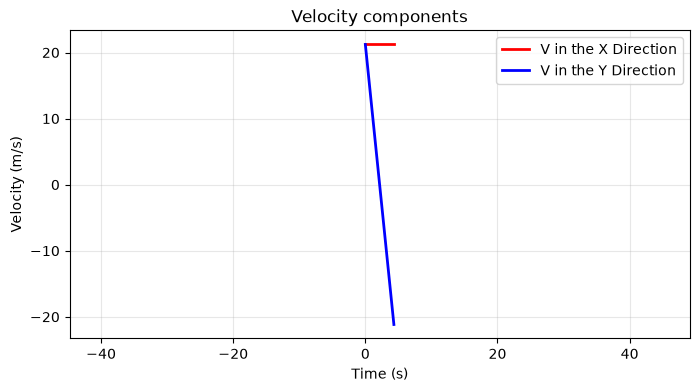

In [7]:
# Part 4
plt.figure(figsize=(8, 4))
plt.plot(t, vx, color="red",label='V in the X Direction', linewidth=2)
plt.plot(t, vy, color="blue",label='V in the Y Direction', linewidth=2)
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.title('Velocity components')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

As time increases the velocity in the y direction decreases while the velocity in the x direction stays constant.

In [8]:
# Part 5
xc=round(x[-1], 2)
yc=round(y[len(y) // 2],2)
tc=round(t[-1],3)

# Comparing Values
print(f'Exact Range = 91.74 m')
print(f'Exact Max Height = 22.94 m')
print(f'Exact Flight Time = 4.324 s')

print(f'Numerical Range = {xc} m')
print(f'Numerical Max Height = {yc} m')
print(f'Numerical Flight Time = {tc} s')

print(f'Error for Range = {round(((91.74-xc)/xc)*100,3)}%')
print(f'Error for Max Height = {round(((22.94-yc)/yc)*100,3)}%')
print(f'Error for Flight Time = {round(((4.324-tc)/tc)*100,3)}%')

Exact Range = 91.74 m
Exact Max Height = 22.94 m
Exact Flight Time = 4.324 s
Numerical Range = 91.64 m
Numerical Max Height = 22.83 m
Numerical Flight Time = 4.32 s
Error for Range = 0.109%
Error for Max Height = 0.482%
Error for Flight Time = 0.093%


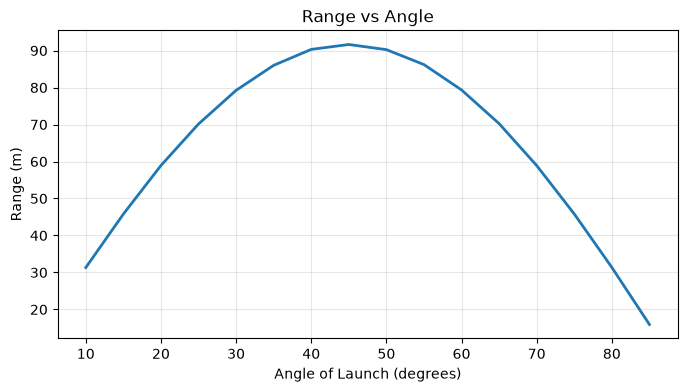

Max Range is 91.64103884177646 and Angle of Launch is 45. So it does match theory.


In [9]:
# Part 6
z=10
x, a, b, c, d, e = simulate_projectile_2d(30,10,0.01)
xs, angle = [x[-1]], [z]
while z <= 80:

    z+=5

    x, a, b, c, d, e = simulate_projectile_2d(30,z,0.01)


    angle.append(z)
    xs.append(x[-1])

plt.figure(figsize=(8, 4))
plt.plot(angle, xs, linewidth=2)
plt.xlabel('Angle of Launch (degrees)')
plt.ylabel('Range (m)')
plt.title('Range vs Angle')
plt.grid(True, alpha=0.3)
plt.show()

print(f'Max Range is {max(xs)} and Angle of Launch is 45. So it does match theory.')

This graph show the max range of the projectile as the angle increases.

Questions:                                                                                             
a. Why is vx constant and vy linear? Connect this to the forces acting on the projectile.

The object has no acceleration in the x direction so the velocity does not change, but it does have a negitive acceleration in the y direction so the velocity decreases.

b. Does the angle for maximum range agree with theory? Should it, given your assumptions?

It does match with theory. Yes

c. What happens if you increase dt to 0.5? Show a plot and explain what goes wrong.

The graph becomes horribly inaccurate because when dt increases less points are measured causing there to be gaps in the data. Plot show below.

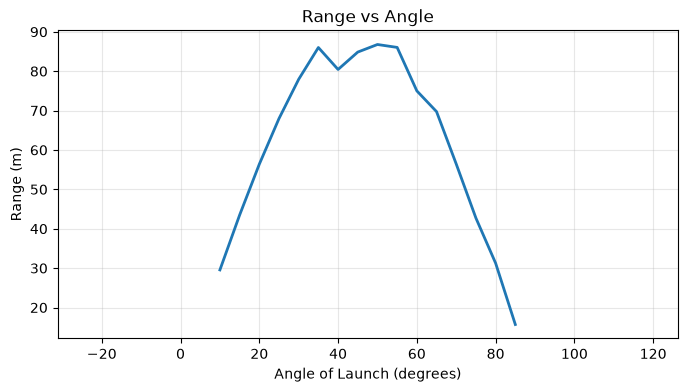

In [10]:
z = 10
x, a, b, c, d,e = simulate_projectile_2d(30,10,0.5)
xs, angle = [x[-1]], [z]
while z <= 80:

    z+=5

    x, a, b, c, d,e = simulate_projectile_2d(30,z,0.5)


    angle.append(z)
    xs.append(x[-1])

plt.figure(figsize=(8, 4))
plt.plot(angle, xs, linewidth=2)
plt.xlabel('Angle of Launch (degrees)')
plt.ylabel('Range (m)')
plt.title('Range vs Angle')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

This graph show the max range of the projectile as the angle increases but with a dt of 0.5.

Part C — Projectile with Air Resistance (35 points)

In [11]:
# Part 1 
# Define Function
def simulate_projectile_drag(v0,theta_deg,dt,g,b_over_m):
    angle = np.radians(theta_deg)
    x, y = 0.0, 0.0   # statrting postition
    vx, vy = v0 * np.cos(angle), v0 * np.sin(angle)

    xs_drag, ys_drag, vx_drag, vy_drag, t_drag, speed_drag= [x], [y], [vx], [vy], [0.0], [np.sqrt(vx**2 + vy**2)]

    t = 0.0
    while y >= 0.0:
        # Speed (magnitude of velocity)
        speed = np.sqrt(vx**2 + vy**2)

        # Forces: gravity + drag
        Fx = -(b_over_m) * speed * vx
        Fy = -g - (b_over_m) * speed * vy

        # Euler update
        vx += Fx * dt
        vy += Fy * dt
        x += vx * dt
        y += vy * dt

        t += dt
        xs_drag.append(x)
        ys_drag.append(y)
        t_drag.append(t)
        vx_drag.append(vx)
        vy_drag.append(vy)
        speed_drag.append(speed)

    return xs_drag, ys_drag, vx_drag, vy_drag, t_drag, speed_drag

In [12]:
# Part 2
# Setting Constants
v0 = 45 
theta_deg = 40
b_over_m = 0.0046 
dt = 0.01 
g = 9.81

# Calling the function
xs_drag, ys_drag, vx_drag, vy_drag, t_drag, speed_drag = simulate_projectile_drag(v0,theta_deg,dt,g,b_over_m)
xs, ys, vxs, vys, ts, speed_s = simulate_projectile_2d(v0,theta_deg,dt,g)

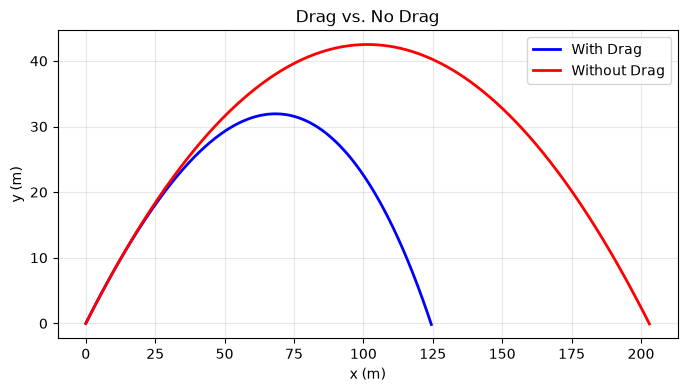

Range With Drag = 124.48m | Max Height With Drag = 31.83m | Time With Drag= 5.09s
Range Without Drag = 203.04m | Max Height Without Drag = 42.50m | Time Without Drag = 5.89s
Drag reduces the max range by 38.69%


In [13]:
# Part 3
# Plotting the Graph
plt.figure(figsize=(8, 4))
plt.plot(xs_drag, ys_drag, color='blue', linewidth=2, label="With Drag")
plt.plot(xs, ys,color="red", linewidth=2, label="Without Drag")
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Drag vs. No Drag')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

#Part 4
print(f'Range With Drag = {xs_drag[-1]:.2f}m | Max Height With Drag = {ys_drag[len(ys_drag) // 2]:.2f}m | Time With Drag= {t_drag[-1]:.2f}s')
print(f'Range Without Drag = {xs[-1]:.2f}m | Max Height Without Drag = {ys[len(ys) // 2]:.2f}m | Time Without Drag = {ts[-1]:.2f}s')
print(f'Drag reduces the max range by {((xs[-1]-xs_drag[-1])/xs[-1])*100:.2f}%')

This graph shows that a projectile does not travel as far when drag is pressent.

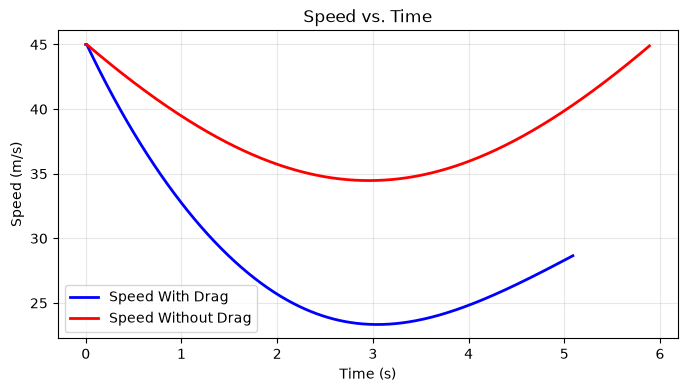

In [14]:
# Part 5

plt.figure(figsize=(8, 4))
plt.plot(t_drag, speed_drag, color='blue', linewidth=2, label="Speed With Drag")
plt.plot(ts, speed_s,color="red", linewidth=2, label="Speed Without Drag")
plt.xlabel('Time (s)')
plt.ylabel('Speed (m/s)')
plt.title('Speed vs. Time')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

This graph shows how speed decreases faster when drag is pressent.

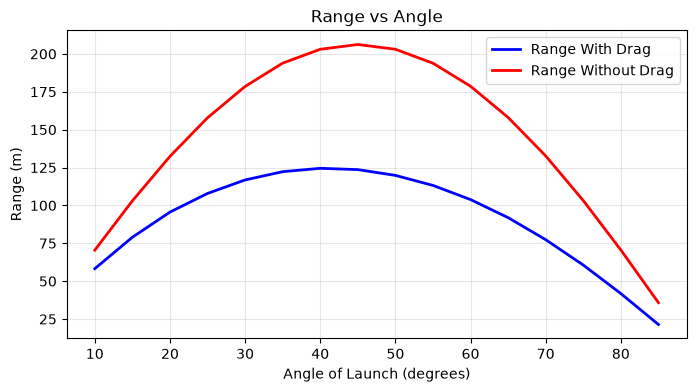

The angle at which range is maximized is 40 degrees.


In [15]:
# Part 6
z = 10
g=9.81
x_drag, a, b, c, d, e = simulate_projectile_drag(v0,10,dt,g,b_over_m)
x, f, ge, h, i, j = simulate_projectile_2d(v0,10,dt,g)

xs, angle, xs_drag = [x[-1]], [z], [x_drag[-1]]

while z <= 80:
    z+=5
    x_drag, a, b, c, d, e = simulate_projectile_drag(v0,z,dt,g,b_over_m)
    x, f, ge, h, i, j = simulate_projectile_2d(v0,z,dt,g)

    angle.append(z)
    xs.append(x[-1])
    xs_drag.append(x_drag[-1])

plt.figure(figsize=(8, 4))
plt.plot(angle, xs_drag, color='blue', linewidth=2, label="Range With Drag")
plt.plot(angle, xs,color="red", linewidth=2, label="Range Without Drag")
plt.xlabel('Angle of Launch (degrees)')
plt.legend()
plt.ylabel('Range (m)')
plt.title('Range vs Angle')
plt.grid(True, alpha=0.3)
plt.show()
print(f'The angle at which range is maximized is 40 degrees.')

This graph show the max range of the projectile as the angle increases with and without drag.

Questions:                                                                                         
a. Why does drag reduce the range so dramatically? (It's not just "drag slows it down" — think about when the drag force is largest and what that does to the trajectory shape.)

The drag force is largest when the velocity is at its highest which is at the start. So it pushes against the velocity making the perabola thinner.

b. Why is the optimal launch angle with drag less than 45°? Give a physical argument. (Hint: think about what happens when the ball spends more time high up vs. moving fast horizontally.)

The drag force is constantly acting the velocity and making the range smaller. So for the object to be able to go further it needs more horizontal velocity to make up for what it lost. Which decreases the angle.

c. Is the Euler method a good choice for this problem? How would you check? (You'll learn better methods in the next module, but think about what could go wrong.)

No it isn't a good choice because it can be very inaccurate if given a large dt value.